In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv(r"C:\Users\User\Desktop\water\water_stats.csv")

In [18]:
df["date_insert"] = pd.to_datetime(df['date_insert'])
df = df.rename(columns= {'date_insert': 'date'})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34146 entries, 0 to 34145
Data columns (total 19 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   id                                   34146 non-null  int64         
 1   date                                 34146 non-null  datetime64[ns]
 2   year                                 34146 non-null  int64         
 3   month                                34146 non-null  int64         
 4   day                                  34146 non-null  int64         
 5   hour                                 34146 non-null  int64         
 6   sensor_id                            34146 non-null  int64         
 7   lat                                  34146 non-null  float64       
 8   lng                                  34146 non-null  float64       
 9   wtempV_°C                            33800 non-null  float64       
 10  conductivi

In [11]:
cols = ['wtempV_°C', 'conductivity_of_solution_ mS_cm',
       'oxidation_reduction_potential_ mV', 'total_suspended_solids_mg_L',
       'turbidity_NTU', 'dissolved_oxygen_concentration _ppm',
       'dissolved_oxygen_concentration_mg_L', 'oxygen_saturation_%',
       'salinity_ppt', 'dissolved_solids _ppm']

## Correlation Matrix ανα αισθητήρα

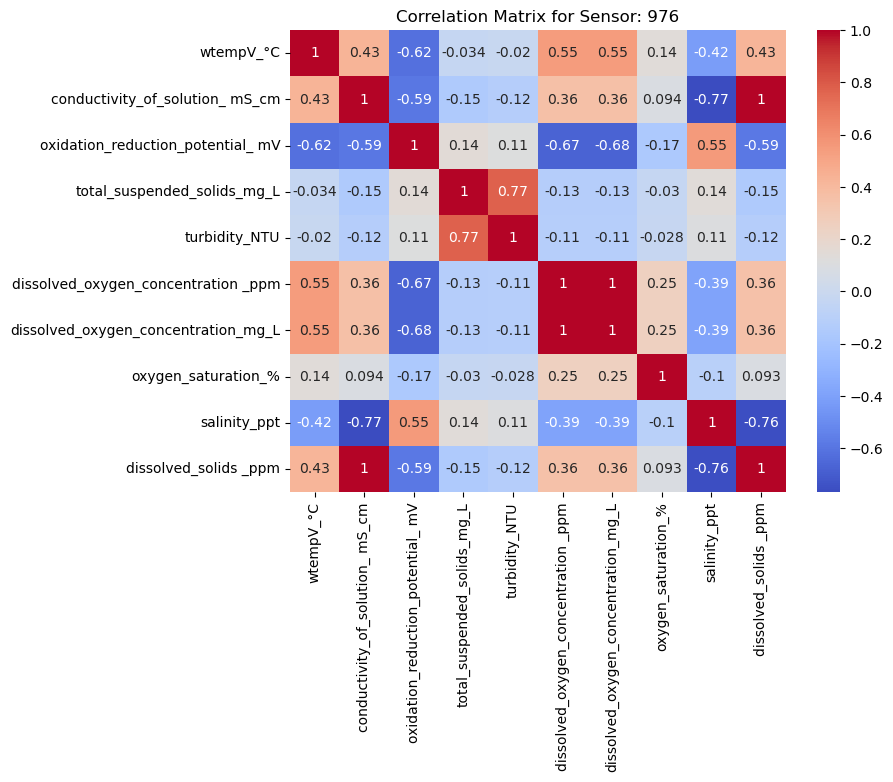

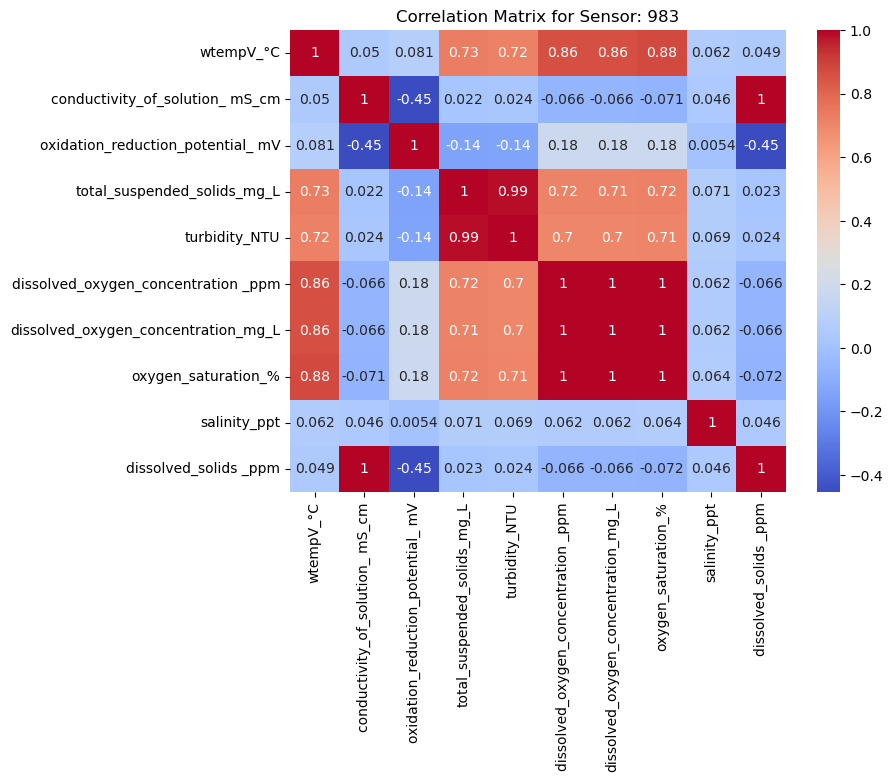

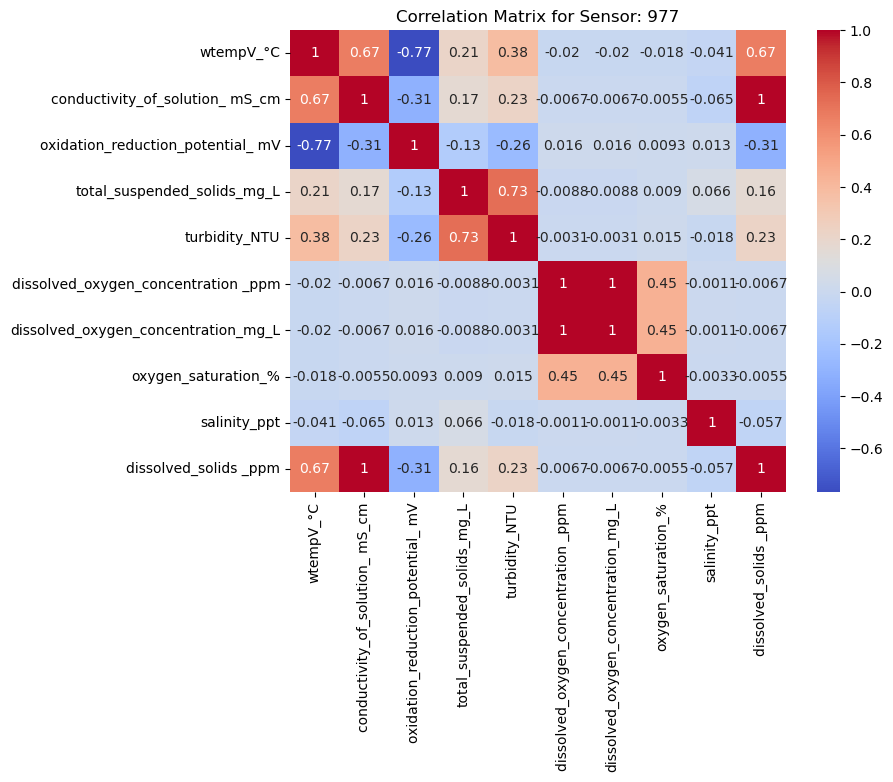

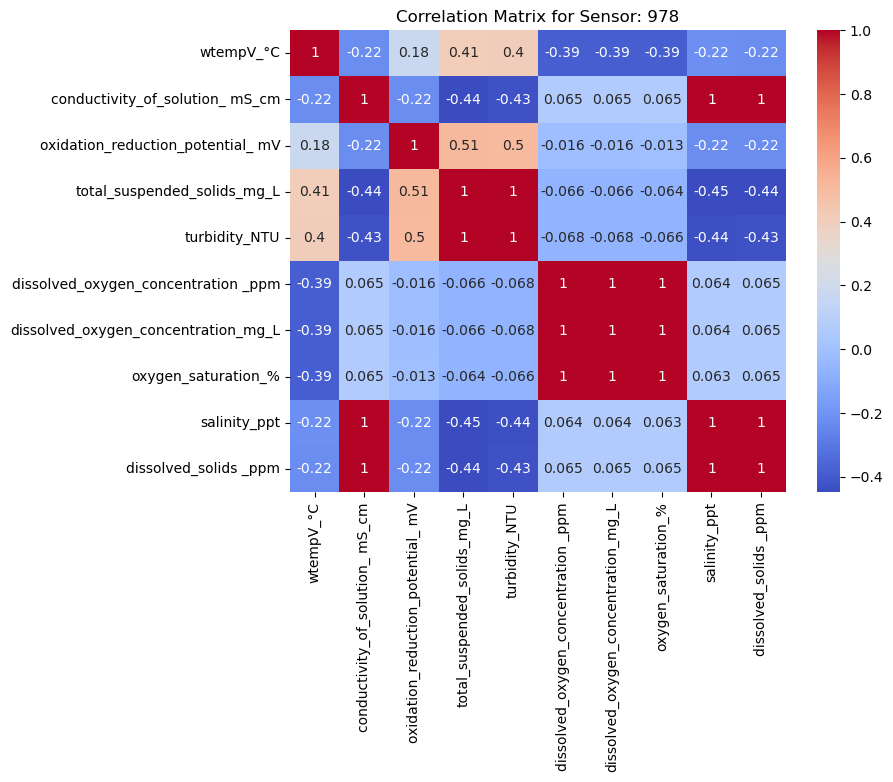

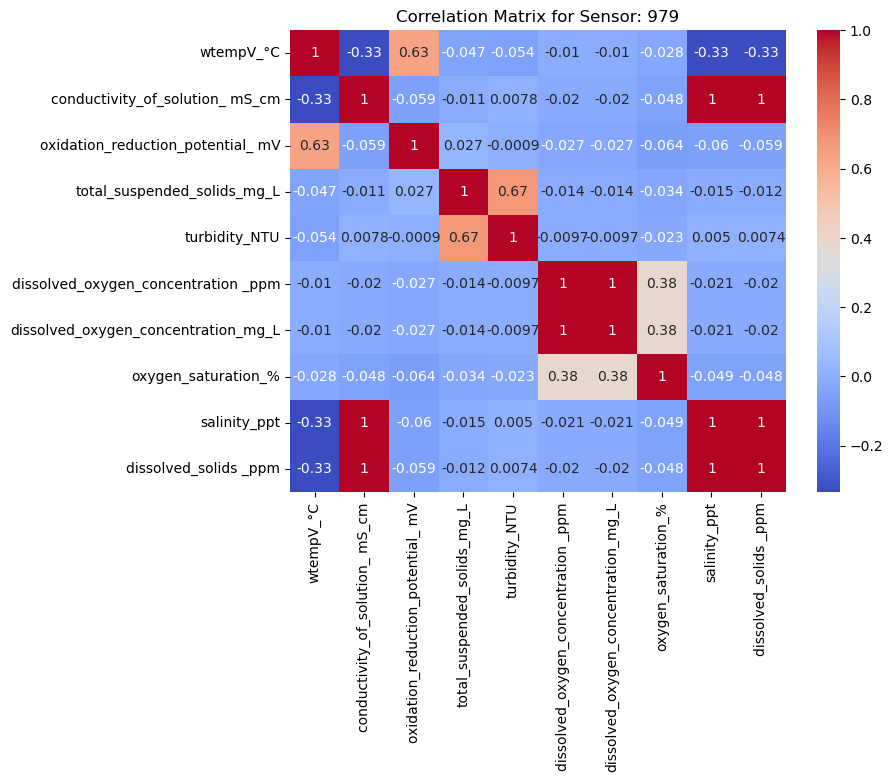

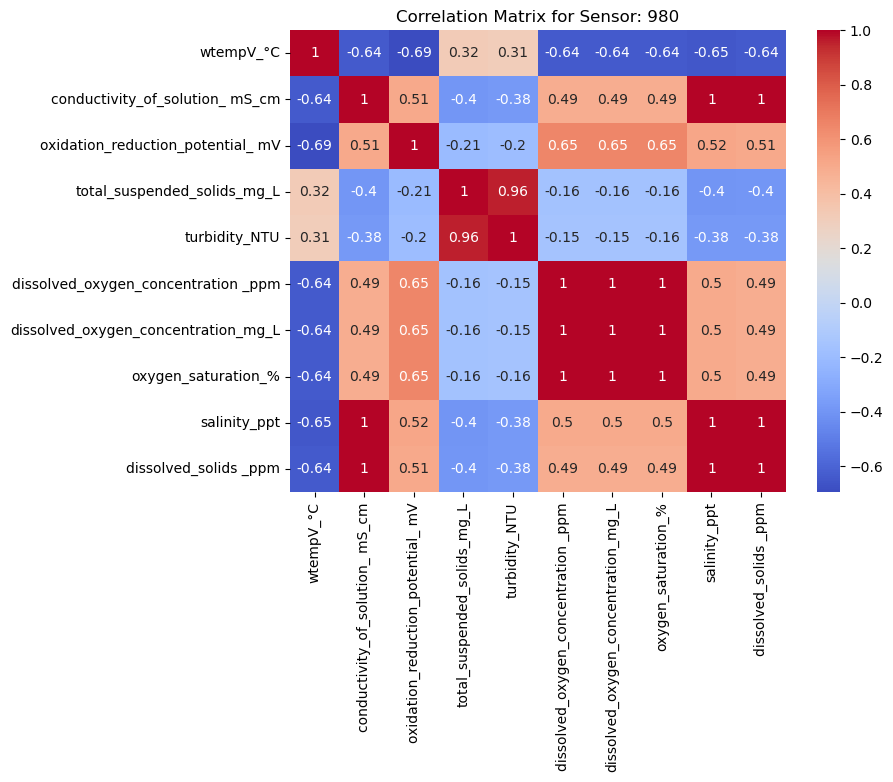

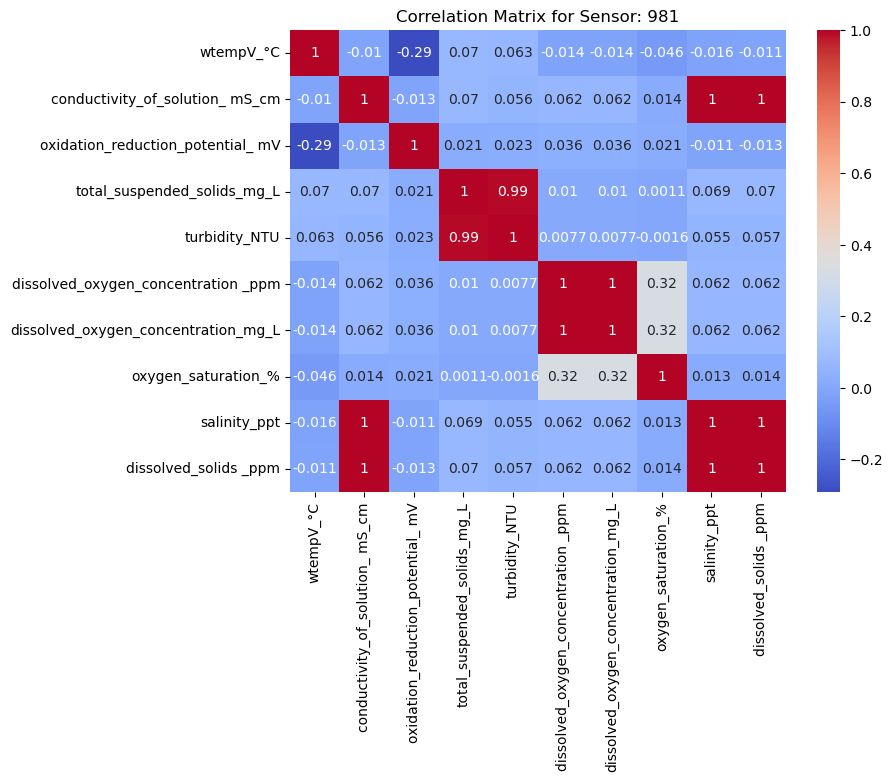

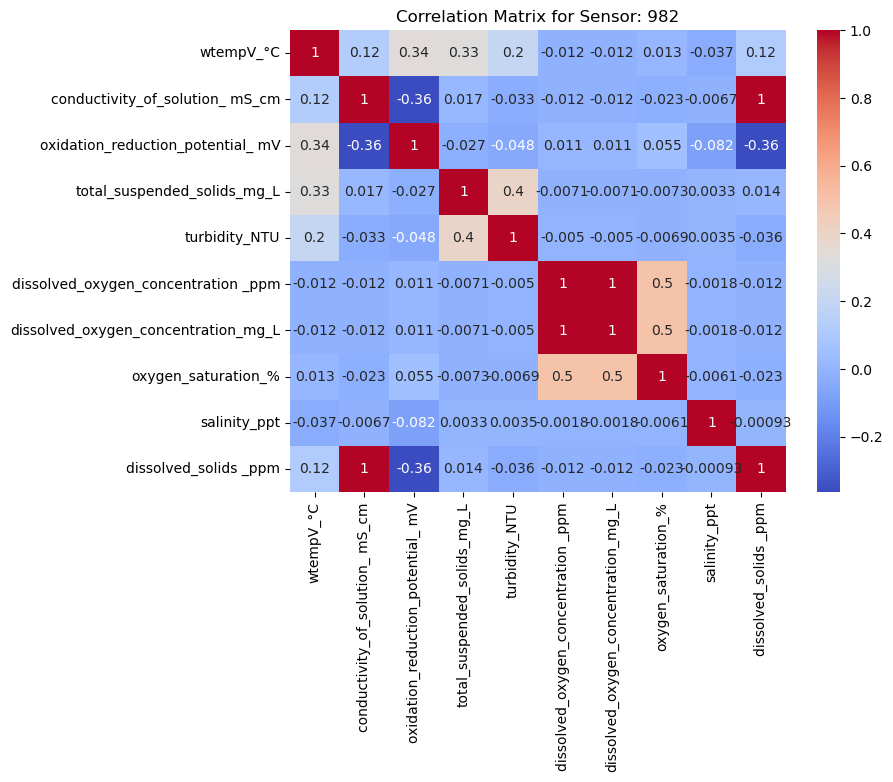

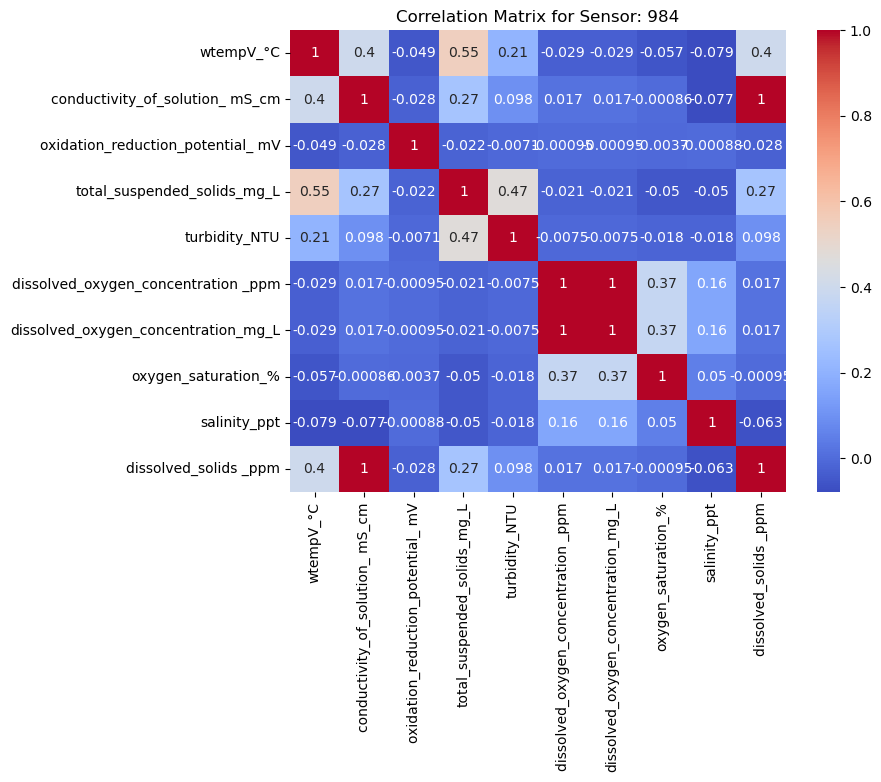

In [12]:
for id in df['sensor_id'].unique():
    corr = df[df['sensor_id'] == id][cols].corr()

    #print(corr)

    plt.figure(figsize=(8,6))

    sns.heatmap(
        corr,
        annot=True,
        cmap="coolwarm"
    )

    plt.title(f"Correlation Matrix for Sensor: {id}")

    plt.show()

Παρατηρώ πως αρκετα στοιχεία έχουν συσχέτιση ακριβως 1, αυτο γινεται επειδη μερικα βγαινουν απο εναν μαθηματικο τυπο του αλλου, ή μετρανε το ιδιο με διαφορετικη μοναδα μετρησης

In [13]:
metrics = ['wtempV_°C',
 'conductivity_of_solution_ mS_cm',
 'oxidation_reduction_potential_ mV',
 'turbidity_NTU',
 'oxygen_saturation_%'
 ]

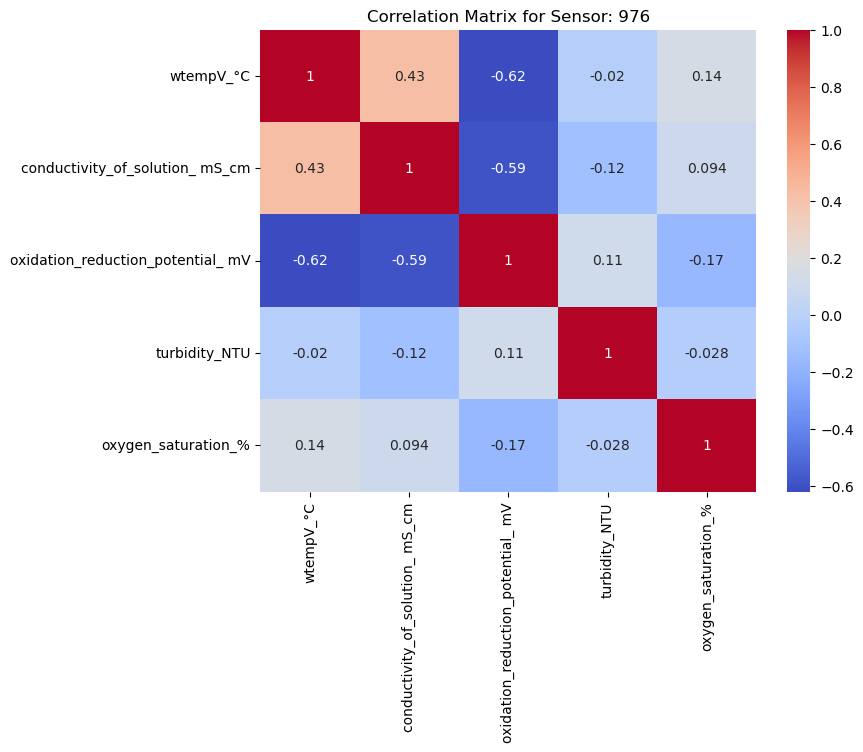

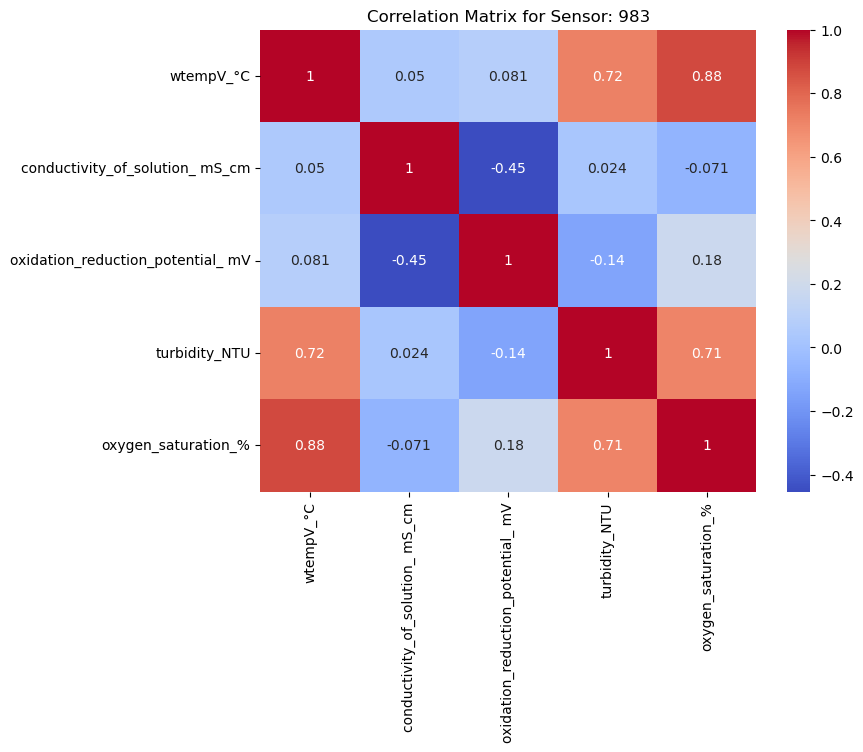

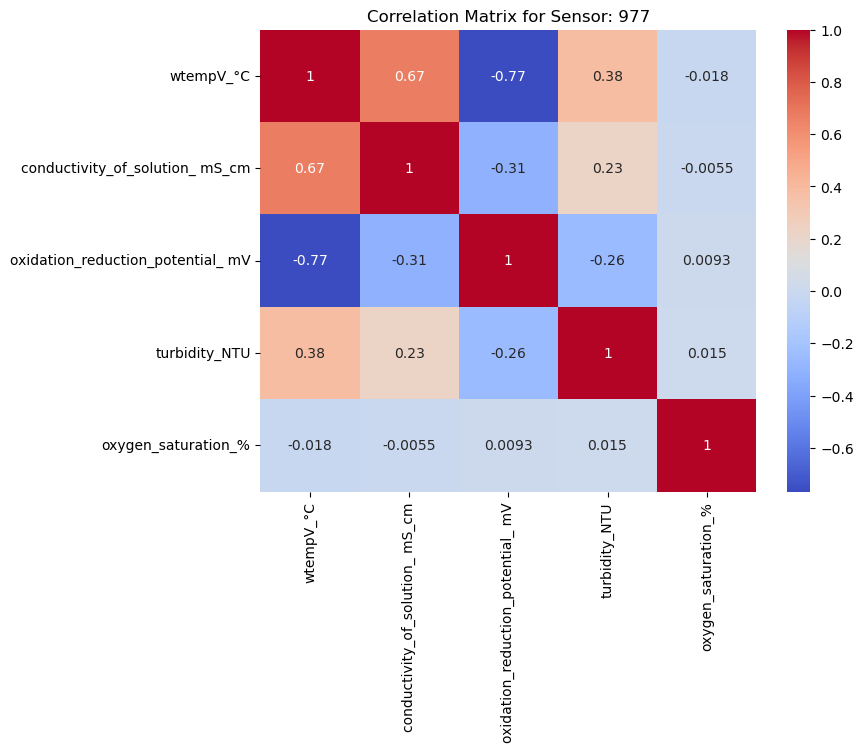

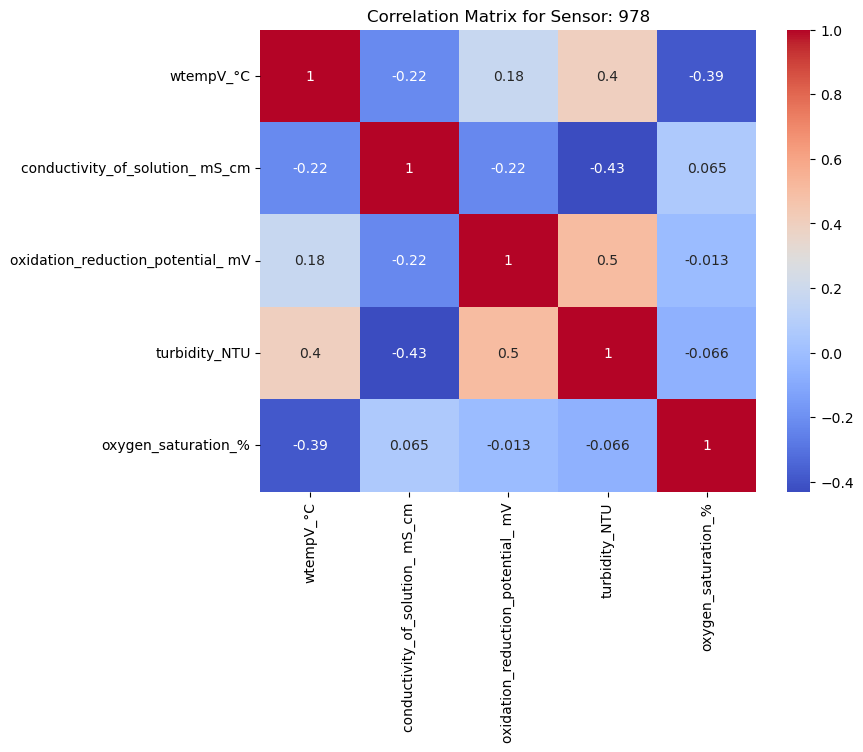

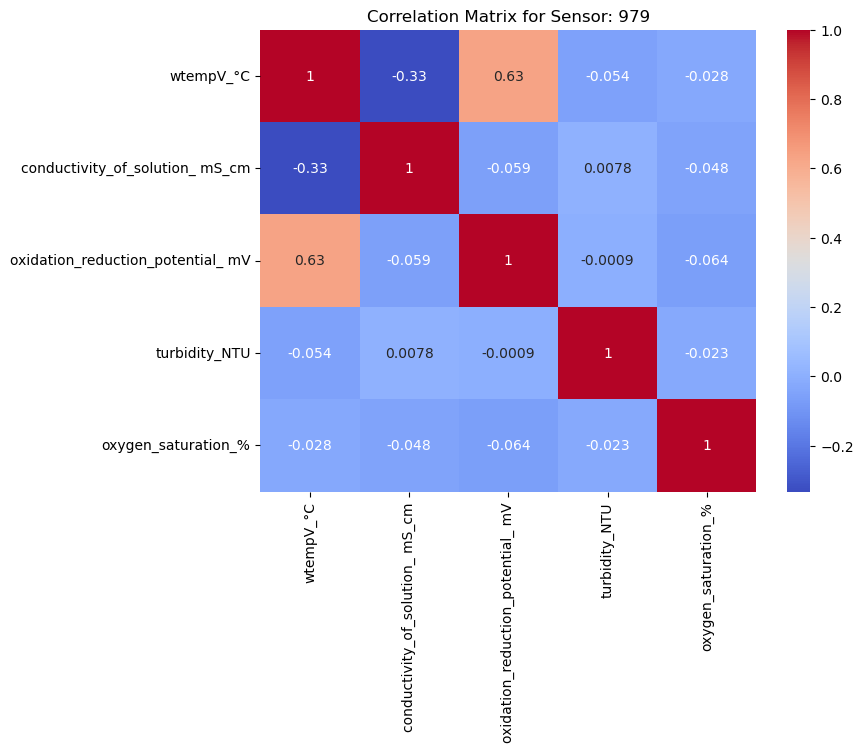

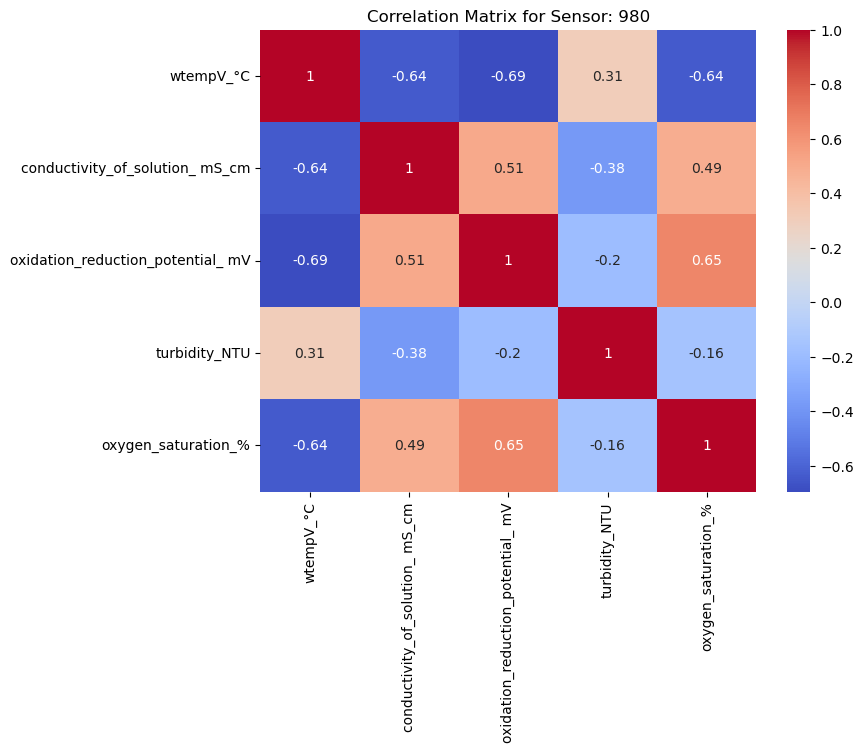

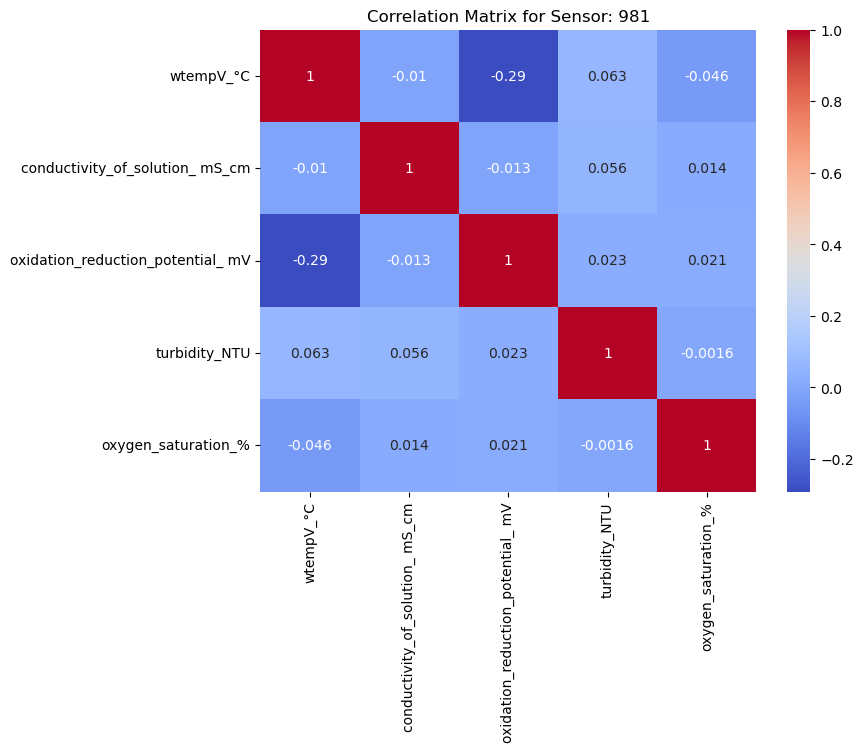

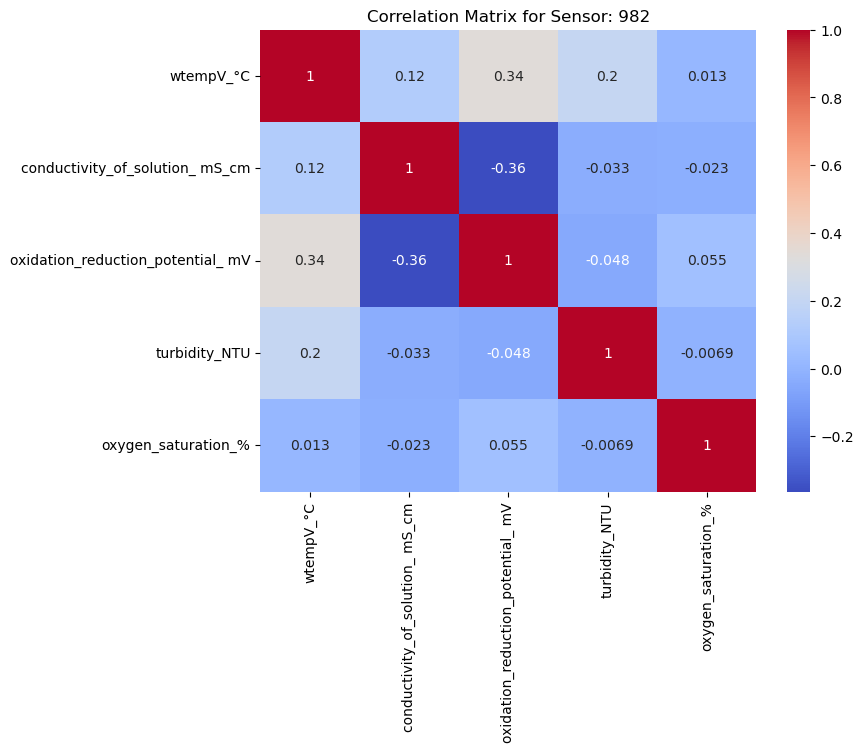

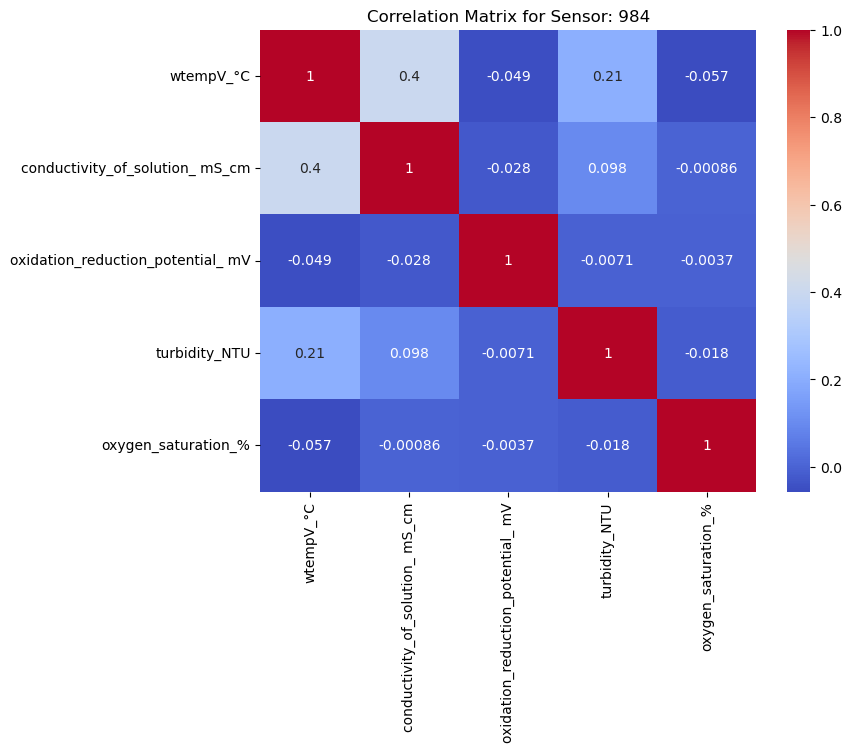

In [14]:
for id in df['sensor_id'].unique():
    corr = df[df['sensor_id'] == id][metrics].corr()

    #print(corr)

    plt.figure(figsize=(8,6))

    sns.heatmap(
        corr,
        annot=True,
        cmap="coolwarm"
    )

    plt.title(f"Correlation Matrix for Sensor: {id}")

    plt.show()

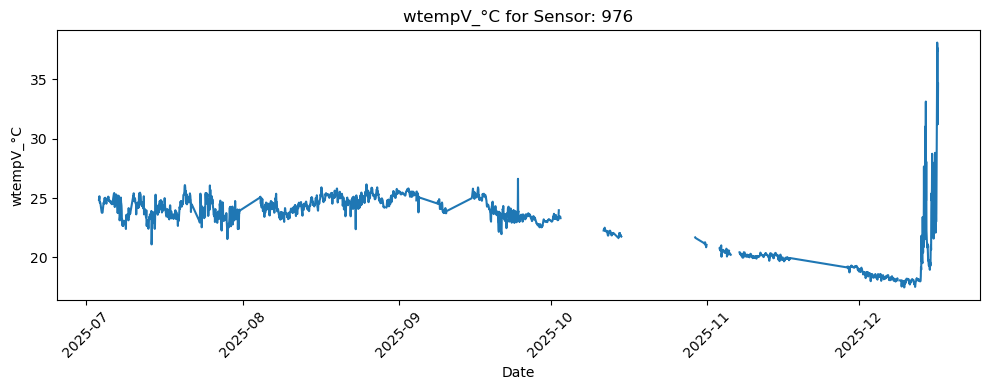

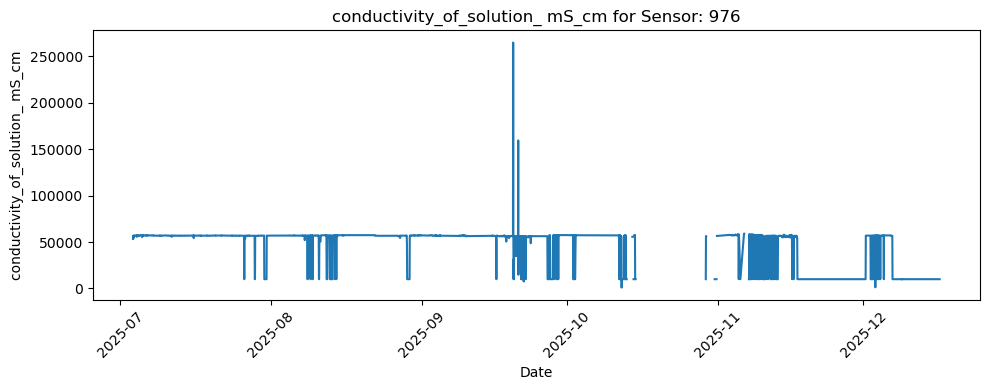

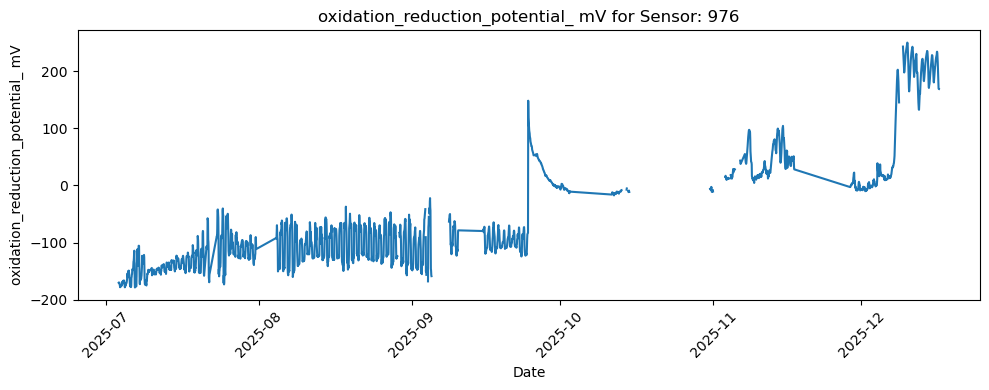

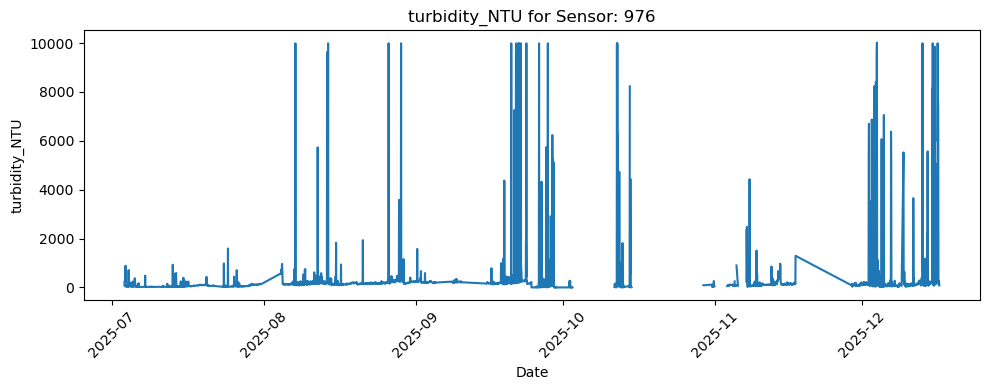

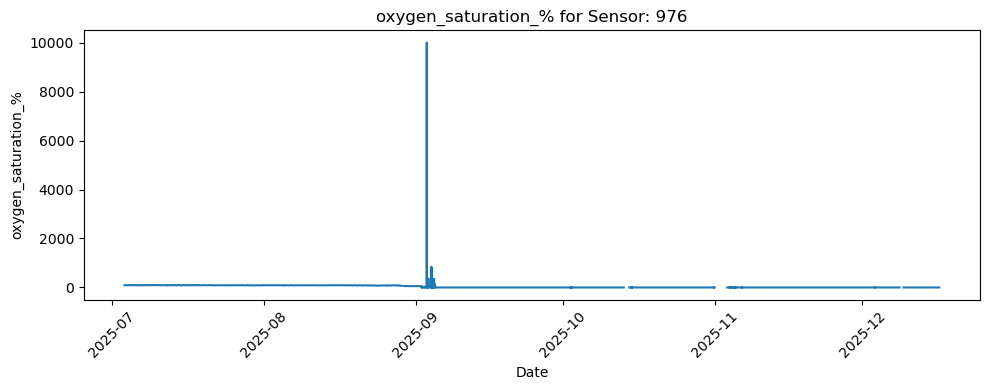

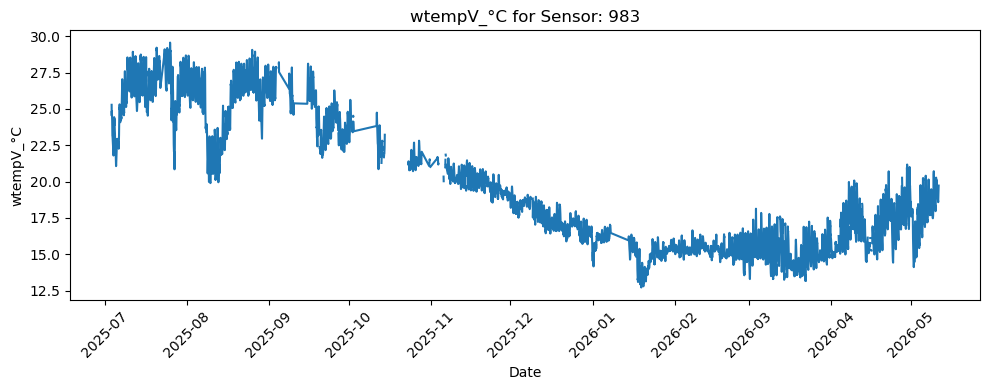

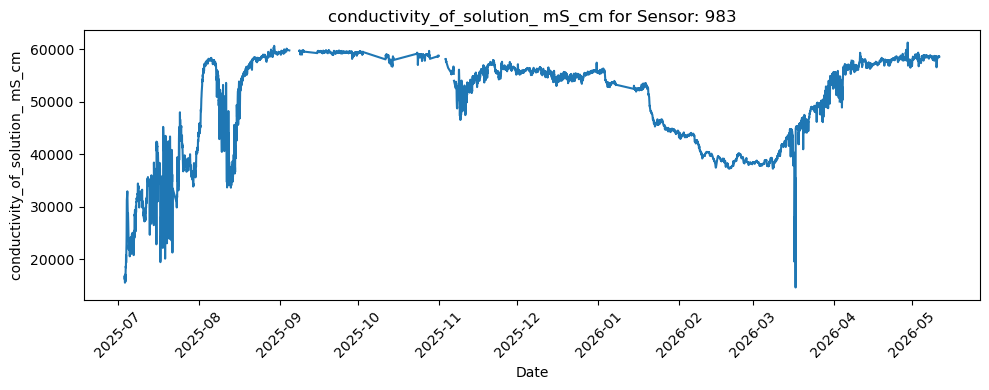

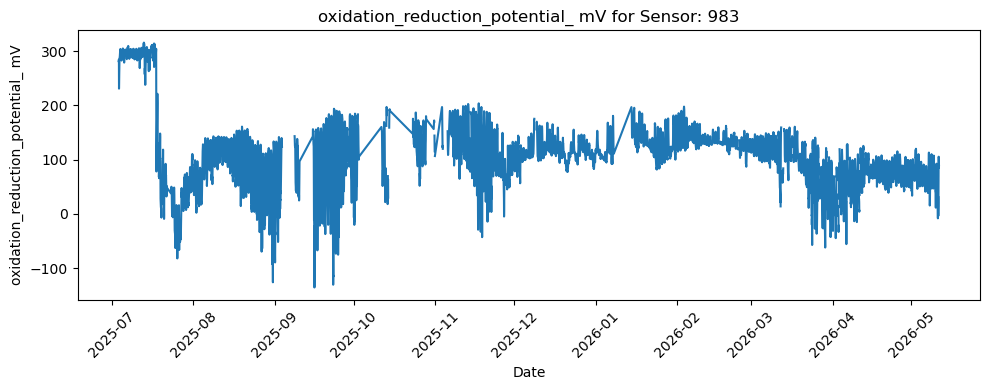

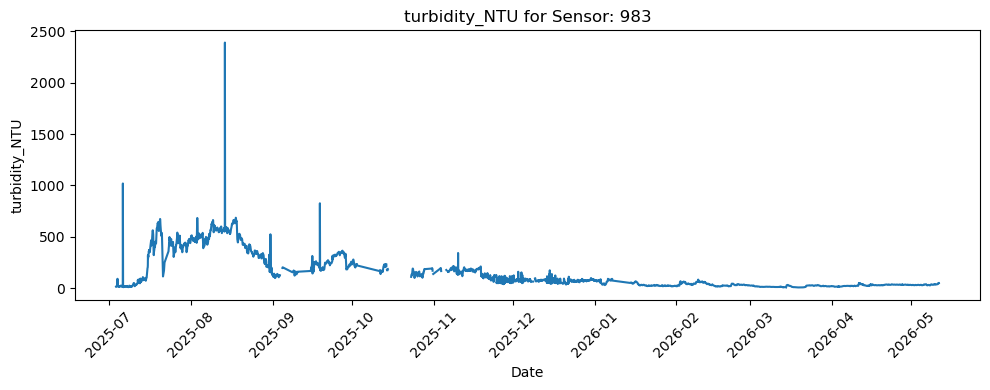

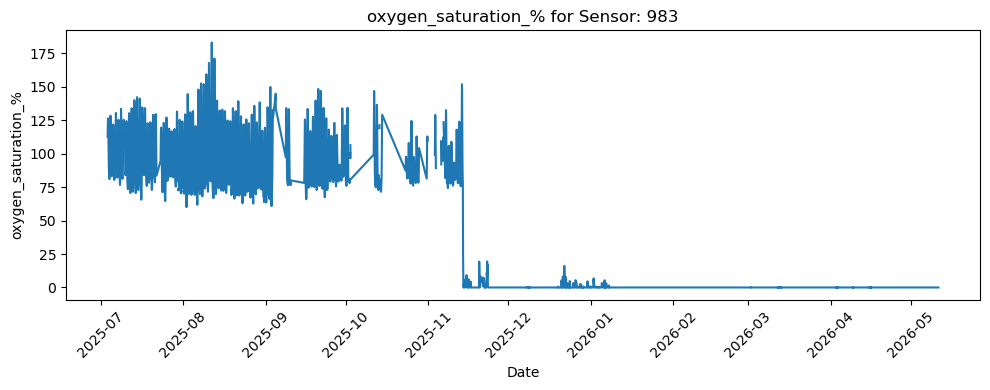

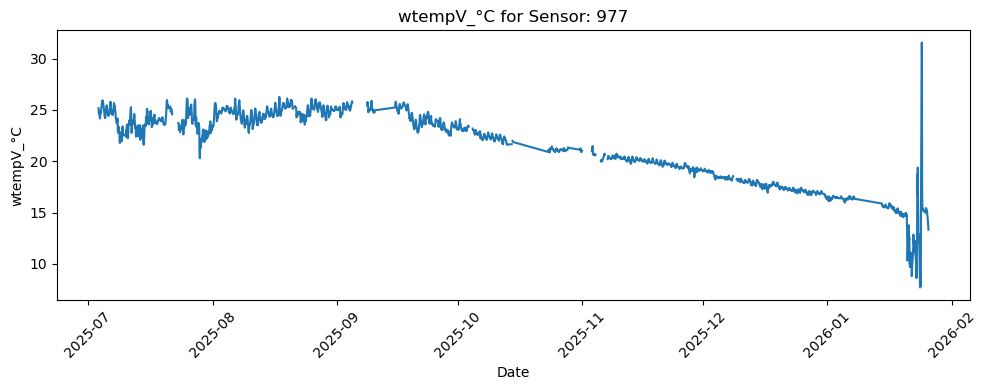

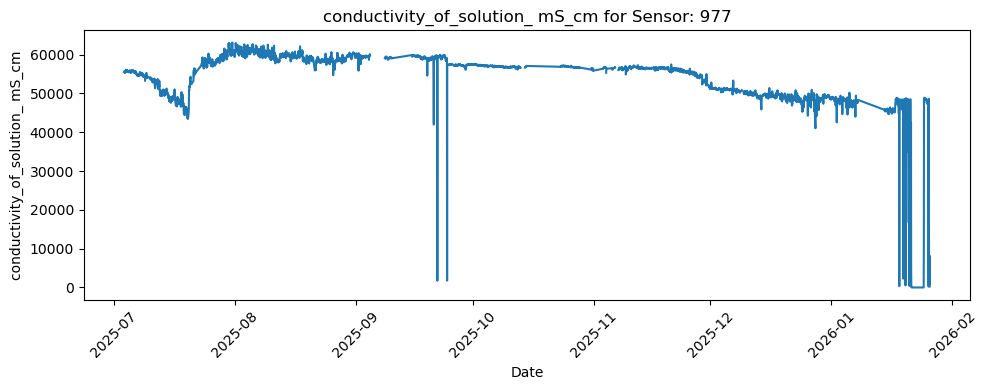

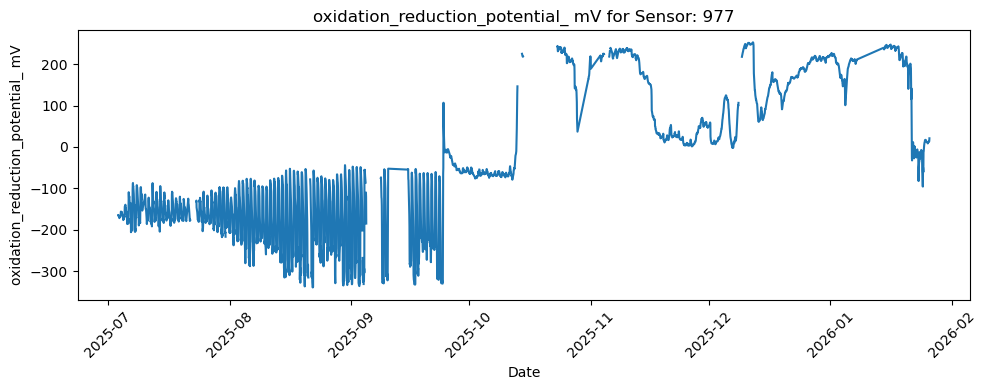

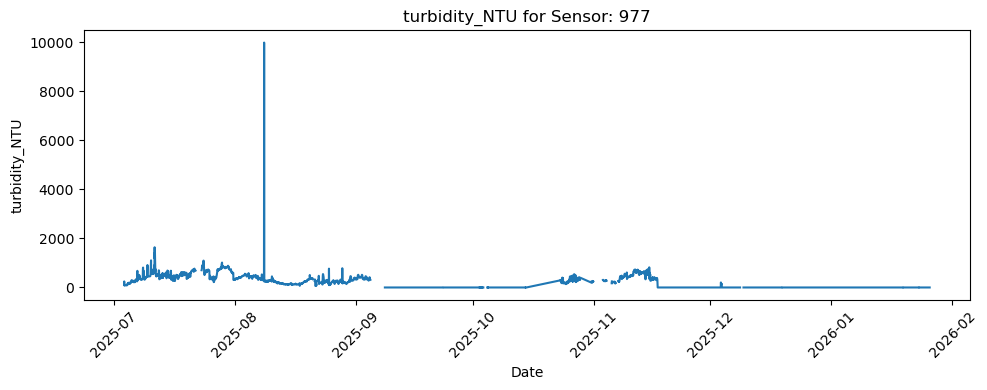

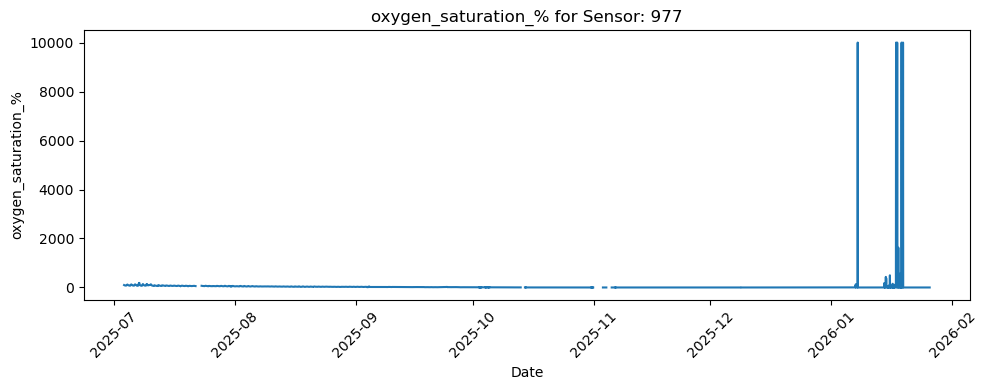

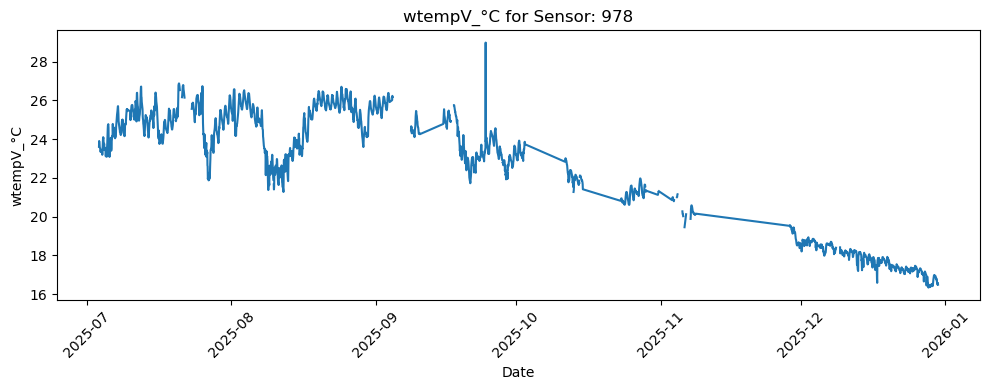

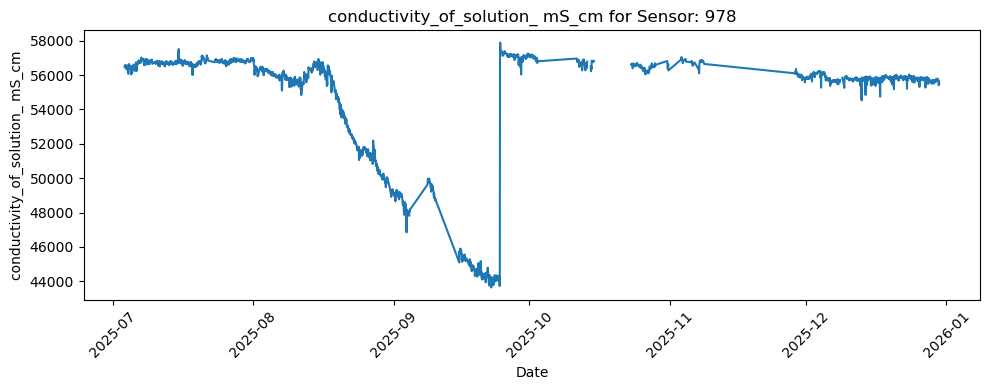

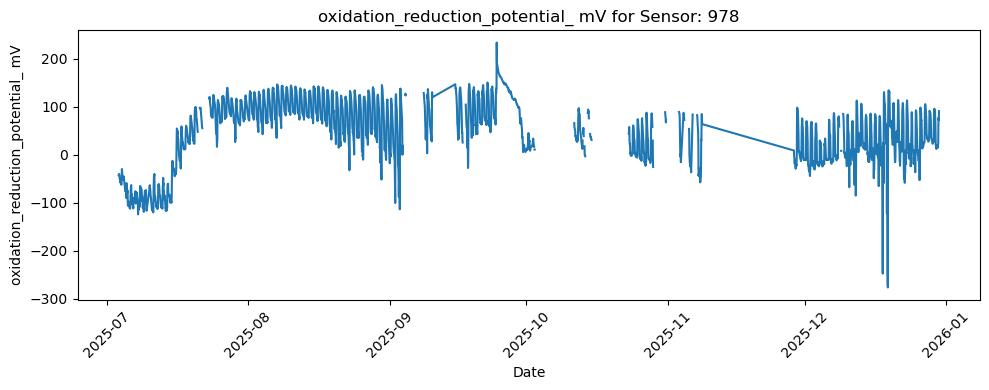

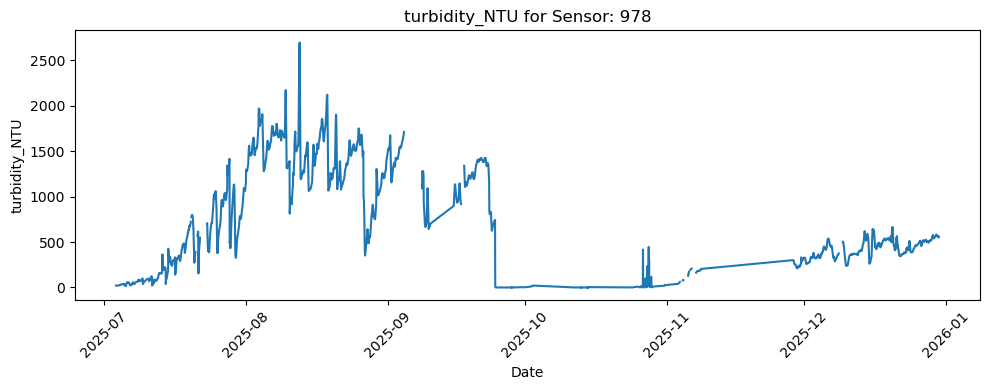

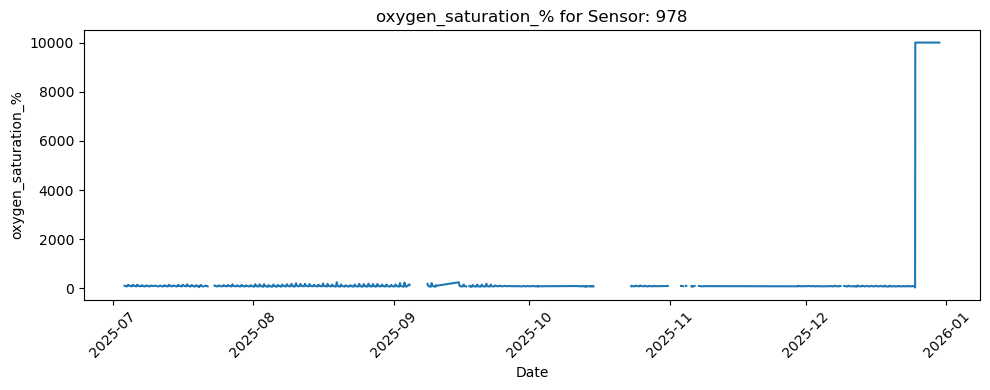

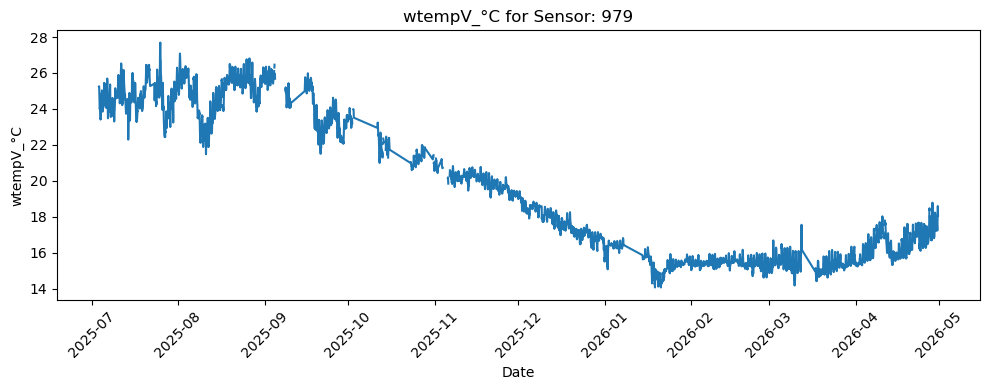

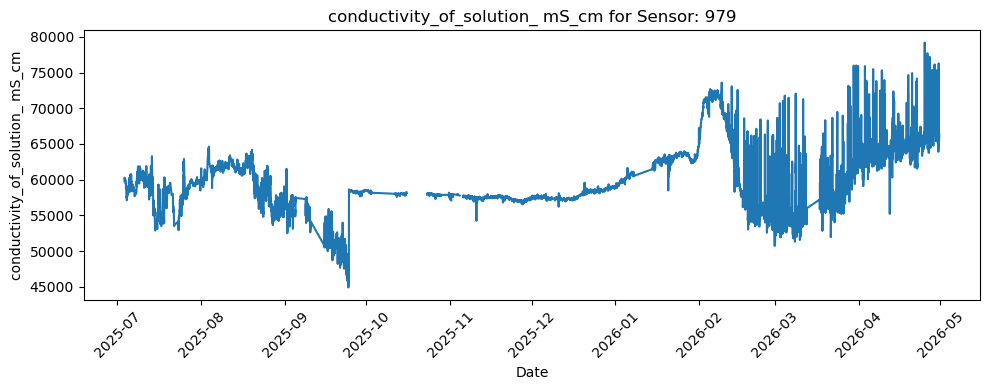

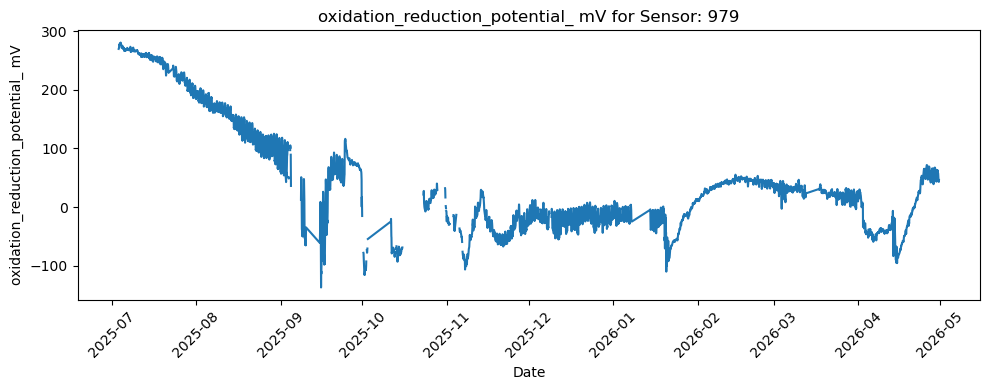

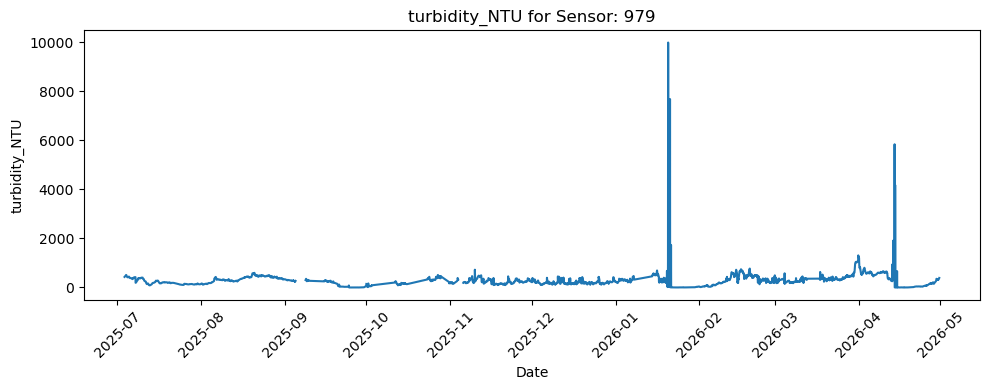

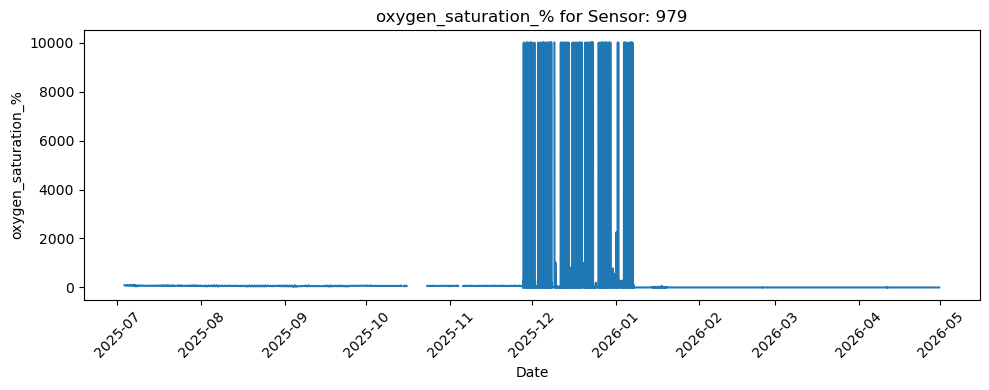

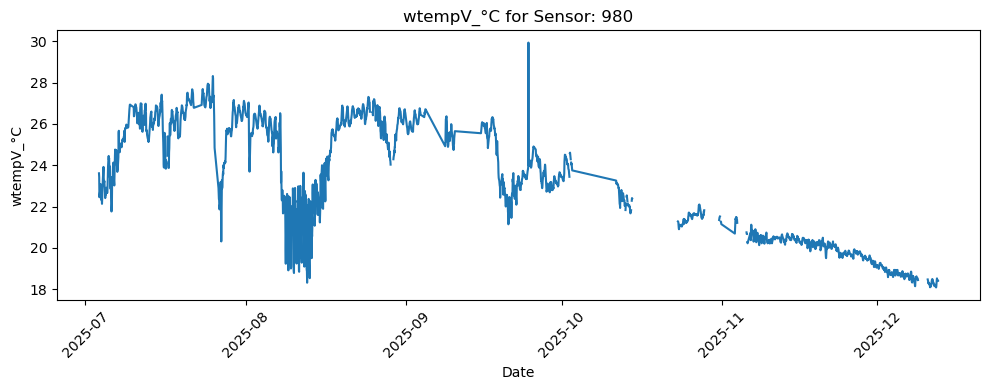

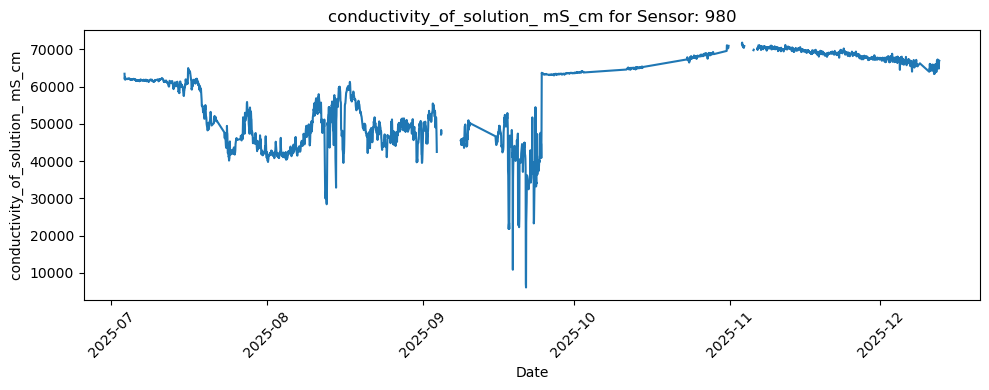

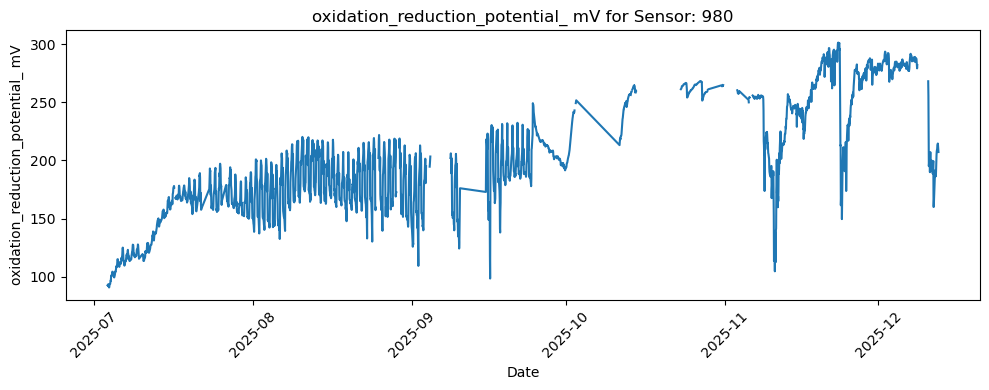

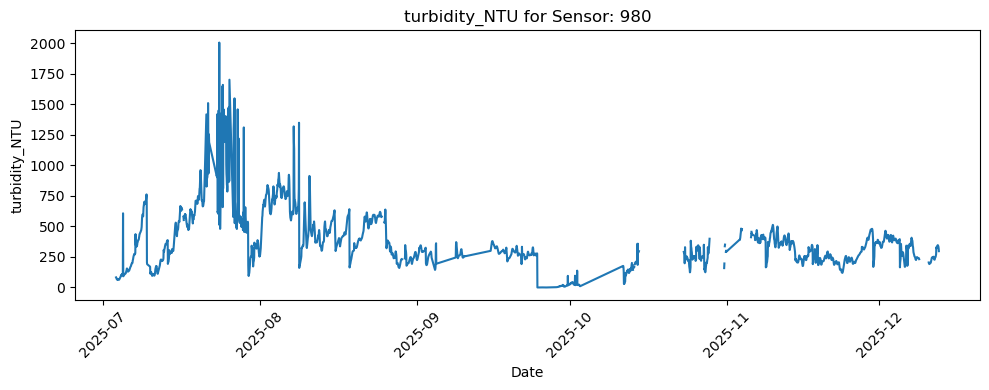

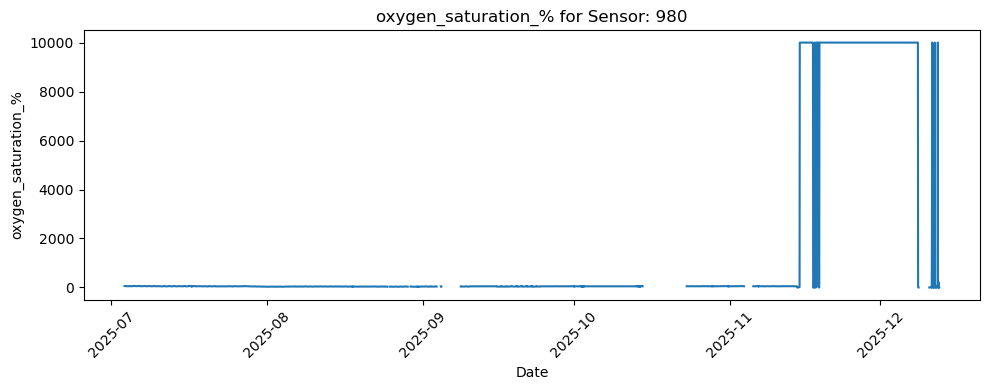

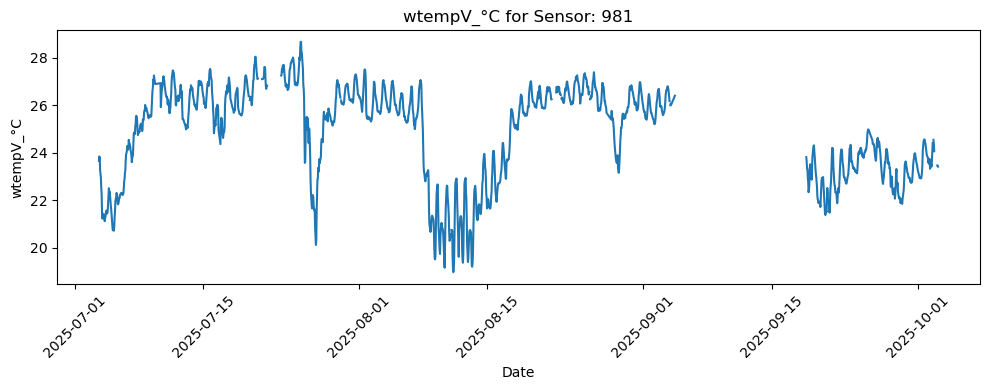

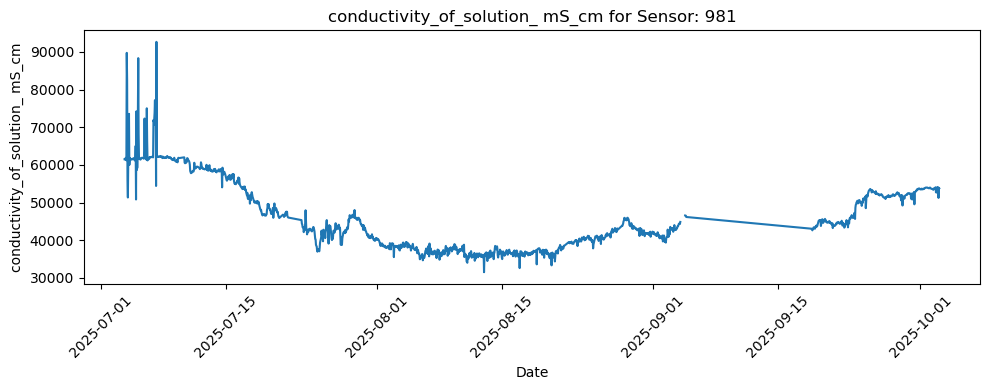

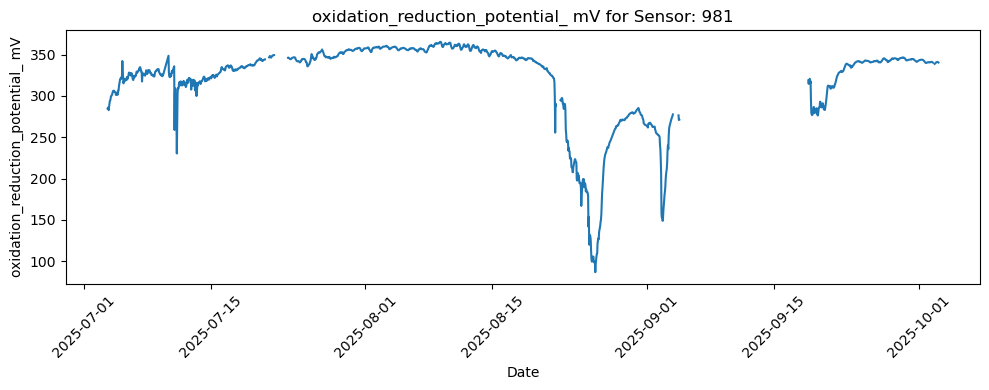

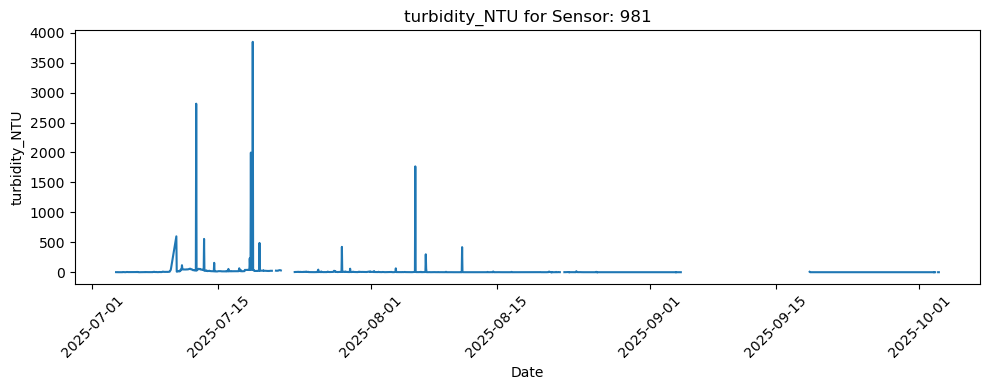

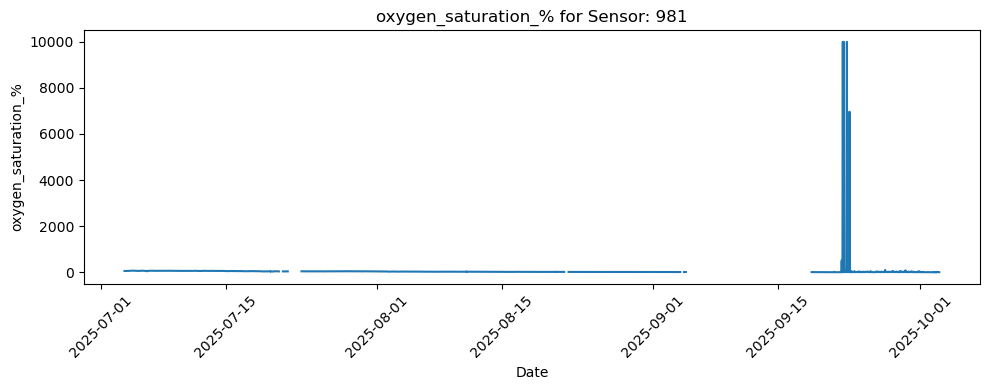

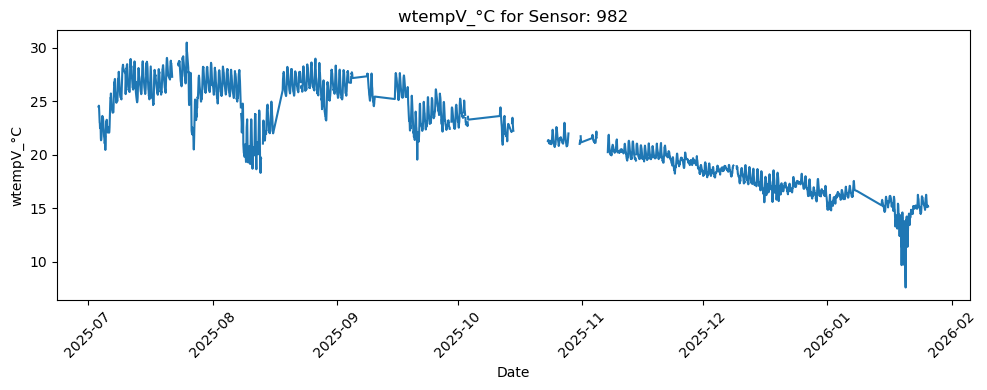

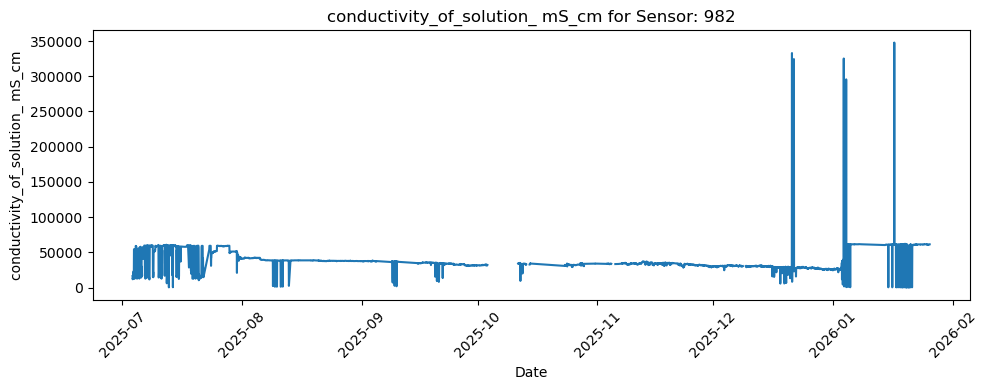

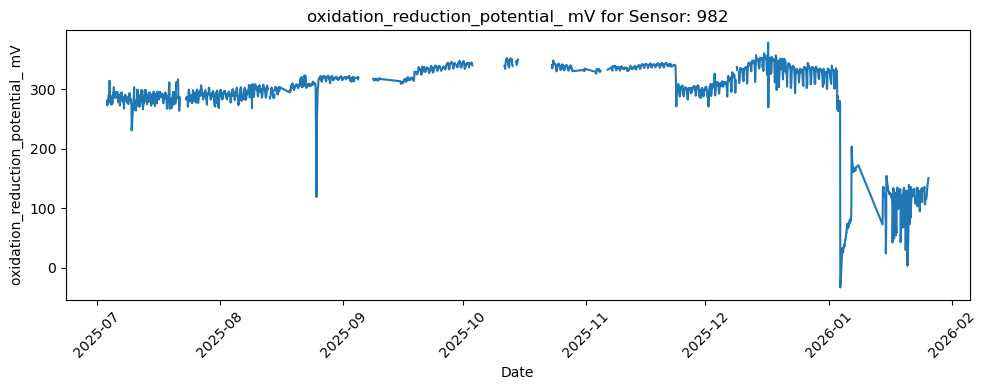

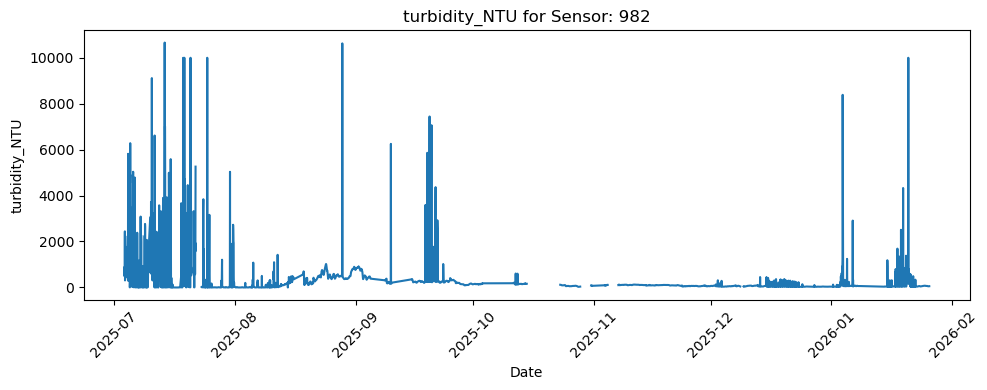

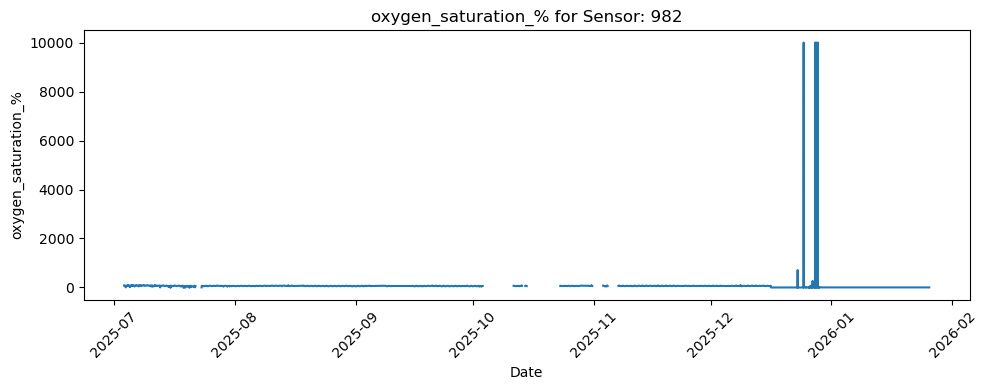

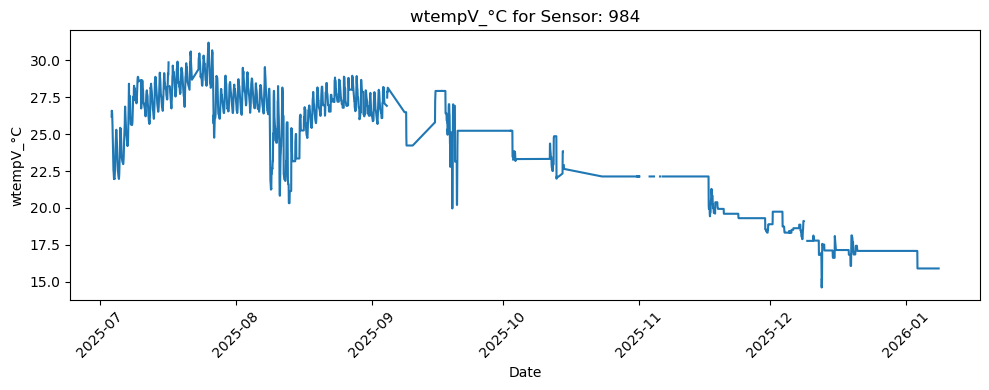

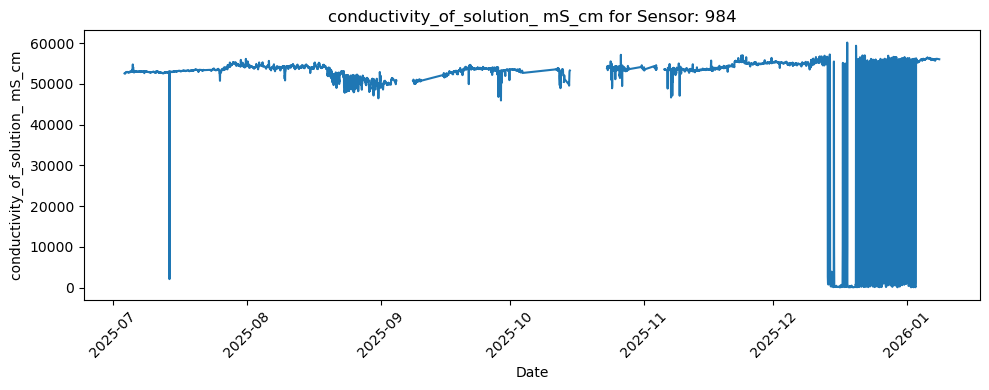

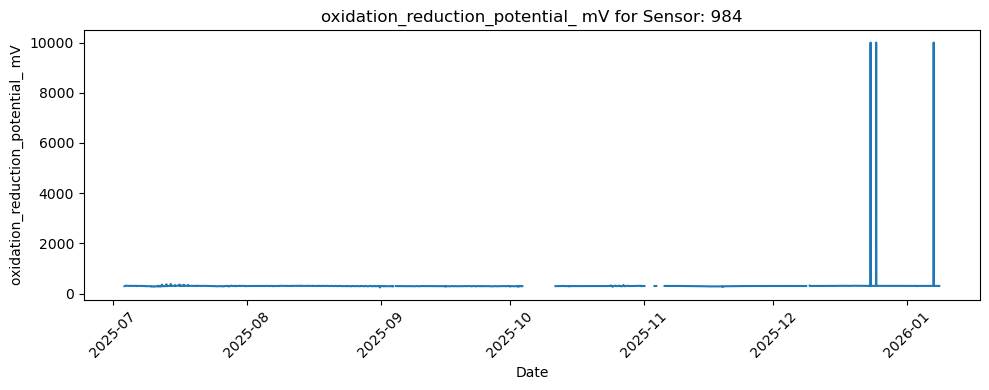

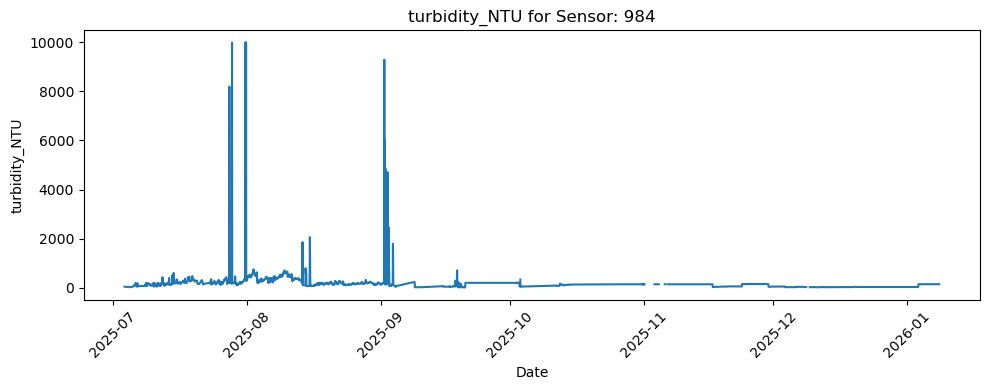

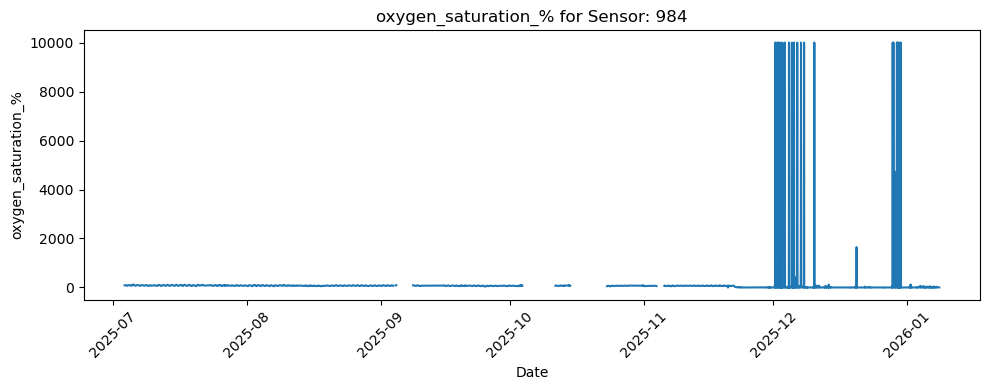

In [19]:
for id in df['sensor_id'].unique():
    for metric in metrics:
        plt.figure(figsize=(10,4))
        
        plt.plot(df[df['sensor_id'] == id]["date"], df[df['sensor_id'] == id][metric] )
        
        plt.title(f"{metric} for Sensor: {id}")
        plt.xlabel("Date")
        plt.ylabel(metric)
        
        plt.xticks(rotation=45)
        plt.tight_layout()
        
        plt.show()

Ξεκάθαρα εμφανίζονται προβλήματα (λογο βλαβών αισθητήρων)